In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms

from pathlib import Path

In [65]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(device)

cuda


In [98]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

In [99]:
data_dir = Path(r"D:\projects\FoodLens\Data")

train_dataset = datasets.CIFAR10(
    root=data_dir,
    train=True,
    transform=train_transform,
    download=False
)

test_dataset = datasets.CIFAR10(
    root=data_dir,
    train=False,
    transform=test_transform,
    download=False
)

C:\Users\kavya\AppData\Roaming\Python\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [100]:
from torch.utils.data import DataLoader

In [101]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [102]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


In [103]:
class CIFAR10(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [104]:
model = CIFAR10().to(device)

images, labels = next(iter(train_loader))

images = images.to(device)

output = model(images)

print(output.shape)

torch.Size([64, 10])


In [106]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 25

In [107]:
train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        # Track accuracy
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/25] Loss: 1.4460 Accuracy: 47.05%
Epoch [2/25] Loss: 1.0889 Accuracy: 61.19%
Epoch [3/25] Loss: 0.9650 Accuracy: 65.77%
Epoch [4/25] Loss: 0.8684 Accuracy: 69.67%
Epoch [5/25] Loss: 0.8158 Accuracy: 71.85%
Epoch [6/25] Loss: 0.7570 Accuracy: 73.88%
Epoch [7/25] Loss: 0.7190 Accuracy: 75.32%
Epoch [8/25] Loss: 0.6852 Accuracy: 76.45%
Epoch [9/25] Loss: 0.6564 Accuracy: 77.49%
Epoch [10/25] Loss: 0.6307 Accuracy: 78.55%
Epoch [11/25] Loss: 0.6018 Accuracy: 79.72%
Epoch [12/25] Loss: 0.5822 Accuracy: 80.19%
Epoch [13/25] Loss: 0.5667 Accuracy: 80.72%
Epoch [14/25] Loss: 0.5447 Accuracy: 81.54%
Epoch [15/25] Loss: 0.5361 Accuracy: 81.61%
Epoch [16/25] Loss: 0.5185 Accuracy: 82.36%
Epoch [17/25] Loss: 0.5044 Accuracy: 82.86%
Epoch [18/25] Loss: 0.4927 Accuracy: 83.14%
Epoch [19/25] Loss: 0.4837 Accuracy: 83.66%
Epoch [20/25] Loss: 0.4716 Accuracy: 83.85%
Epoch [21/25] Loss: 0.4585 Accuracy: 84.45%
Epoch [22/25] Loss: 0.4544 Accuracy: 84.69%
Epoch [23/25] Loss: 0.4442 Accuracy: 84.8

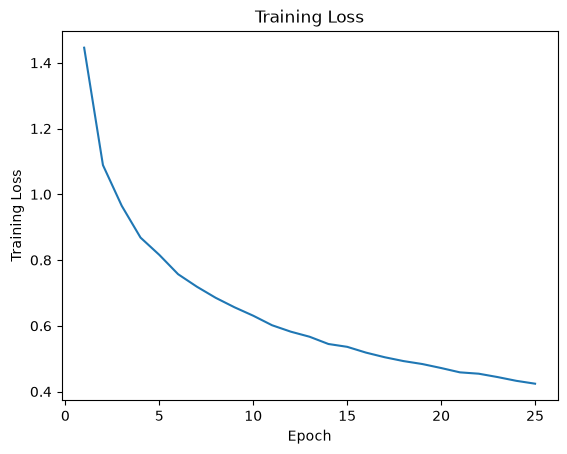

In [108]:
plt.plot(range(1,epochs+1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.show()

In [109]:
correct = 0
total = 0
test_loss = 0.0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.4706
Test Accuracy: 84.43%


In [110]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)

Predictions: (10000,)
Labels: (10000,)


In [111]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[931  12  10   3   4   0   1   6  22  11]
 [  9 946   0   0   1   2   0   0   9  33]
 [ 68   3 741  25  55  31  37  23  10   7]
 [ 32   8  39 626  51 125  41  43  19  16]
 [ 16   3  22  23 865  10  18  36   5   2]
 [ 14   3  13  88  41 776  11  46   1   7]
 [  8   4  30  23  19   8 888  11   5   4]
 [ 25   3  10  10  24  22   1 896   0   9]
 [ 78  12   3   0   0   0   0   3 893  11]
 [ 32  63   2   3   0   0   2   1  16 881]]


In [115]:
model_path = r"D:\projects\FoodLens\Models\ciphar10_cnn.pth"

torch.save(
    model.state_dict(),
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: D:\projects\FoodLens\Models\ciphar10_cnn.pth


In [116]:
import json

class_names = train_dataset.classes

with open(
    r"D:\projects\FoodLens\Models\class_names.json",
    "w"
) as f:
    json.dump(class_names, f)